## Здесь будеn pipeline для работы с видео

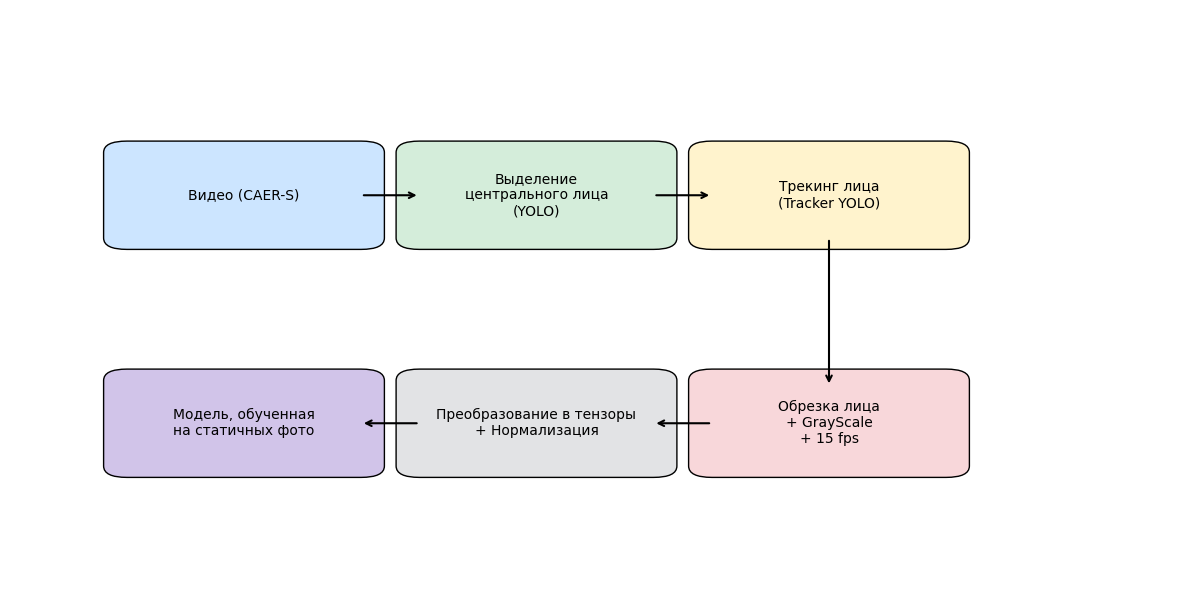

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

blocks = [
    ("Видео (CAER-S)", 0.1, 0.6, 0.2, '#cce5ff'),
    ("Выделение\nцентрального лица\n(YOLO)", 0.35, 0.6, 0.2, '#d4edda'),
    ("Трекинг лица\n(Tracker YOLO)", 0.6, 0.6, 0.2, '#fff3cd'),
    ("Обрезка лица\n+ GrayScale\n+ 15 fps", 0.6, 0.2, 0.2, '#f8d7da'), # 0.1, 0.2, 0.2
    ("Преобразование в тензоры\n+ Нормализация", 0.35, 0.2, 0.2, '#e2e3e5'),
    ("Модель, обученная\nна статичных фото", 0.1, 0.2, 0.2, '#d1c4e9') # 0.6, 0.2, 0.2
]

for text, x, y, width, color in blocks:
    rect = patches.FancyBboxPatch((x, y), width, 0.15,
                                  boxstyle="round,pad=0.02",
                                  edgecolor='black',
                                  facecolor=color)
    ax.add_patch(rect)
    ax.text(x + width / 2, y + 0.075, text, ha='center', va='center', fontsize=10)

arrows = [
    ((0.3, 0.675), (0.35, 0.675)),
    ((0.55, 0.675), (0.6, 0.675)),
    ((0.7, 0.6), (0.7, 0.34)),
    ((0.6, 0.275), (0.55, 0.275)),
    ((0.35, 0.275), (0.3, 0.275))
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", lw=1.5))

plt.tight_layout()
plt.savefig("video_processing_pipeline.png", dpi=300)
plt.show()


In [1]:
import torch
from torchvision.transforms import v2 as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

from torch.utils.data import DataLoader, Dataset


from ultralytics import YOLO

import os
import cv2
import time
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# https://huggingface.co/arnabdhar/YOLOv8-Face-Detection/blob/main/fine-tune-artifacts/results.png
# "models/Yolo_face_detection.pt"

model = YOLO("models/Yolo_face_detection.pt")

In [2]:
def write_video(directory='/', name='test_video'):

    os.makedirs(directory, exist_ok=True)
    filename = os.path.join(directory, name)

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video_writer = cv2.VideoWriter(filename, fourcc, 15.0, (48, 48))

    return video_writer

In [3]:
def transform_image(orig_img):
    image = cv2.resize(orig_img, (48, 48), interpolation=cv2.INTER_AREA)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    colorful = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR) 
    return colorful

In [4]:
def delete_video_and_log(path, log_file='errors.txt'): # if error
    try: 
        if os.path.exists(path):
            os.remove(path)
            with open(log_file, 'a') as f:
                f.write(f"{path}\n")
            print(f"Deleted: {path} and logged to {log_file}")
        else:
            print(f"File not found: {path}")
    except Exception as e:
        print(f"Error deleting {path}: {e}")


In [6]:
def video_preprocessing(path_to_read, directory_to_save, name_to_save):
    results = model.track(path_to_read, stream=True)
    video_writer = write_video(directory=directory_to_save, name=name_to_save)

    is_cannot_use = False
    try:
        is_first=True
        for frame_id, result in enumerate(results):
            if frame_id%2==0: # даём кадр на начало трекинга и переводим видео в формат 15 кадров в секунду
                continue
            
            boxes = result.boxes

            if is_first:    # находим лучшего кандидата для отслеживания
                coordinates_all = boxes.xywhn
                confs = boxes.conf
                id_all = boxes.id

                best_distance_from_center = 1000
                best_id = -1
                
                for id_current, cur_conf, coords in zip(id_all, confs, coordinates_all):         # Определяем лучший id
                    if cur_conf < 0.78:
                        continue
                    x, y = coords[0], coords[1]
                    distamce_from_center = (x-0.5)**2 + (y-0.5)**2

                    if distamce_from_center < best_distance_from_center:
                        best_distance_from_center = distamce_from_center
                        best_id = id_current

                if best_id == -1:
                    is_cannot_use = True
                    break
                    # raise ValueError("Cant find any faces in video")
                
                is_first=False
                continue
            try:
                try:
                    cur_index = (boxes.id==best_id).nonzero()[0]
                except:
                    cur_index = (boxes.id==best_id).nonzero()
                image = result.orig_img
                try:
                    x1, y1, x2, y2 = [int(i) for i in boxes.xyxy[cur_index][0]]
                except:
                    x1, y1, x2, y2 = [int(i) for i in boxes.xyxy[cur_index]]
            except:
                is_cannot_use = True
                break
            # print(result)
            image_stripped = image[y1:y2, x1:x2]
            frame = transform_image(image_stripped)
            
            video_writer.write(frame)
    except:
        is_cannot_use = True
    finally:
        video_writer.release()
    
    if is_cannot_use:
        delete_video_and_log(path=os.path.join(directory_to_save, name_to_save))



In [ ]:
path_init = 'datasets\\CAER_S\\CAER\\'
path_destination = 'datasets\\CAER_S_splited\\'
for type_of_dataset in os.listdir(path=path_init)[1:2]:
    path_to_dataset = os.path.join(path_init, type_of_dataset)
    path_to_dataset_save = os.path.join(path_destination, type_of_dataset)

    for emotion in os.listdir(path_to_dataset):
        if emotion in ('Anger', 'Happy', 'Neutral', 'Disgust', 'Fear'):
            continue

        print(emotion)
        
        path_to_emotion = os.path.join(path_to_dataset, emotion)
        path_to_emotion_save = os.path.join(path_to_dataset_save, emotion)

        for image_name in os.listdir(path_to_emotion):
            path_to_video = os.path.join(path_to_emotion, image_name)

            #if emotion == 'Fear' and (int(image_name[:4])<305): #skip
             #   continue

            video_preprocessing(path_to_read=path_to_video,
                                 directory_to_save=path_to_emotion_save, 
                                 name_to_save=image_name)
        
    break

            

----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
----------------------------------------------------
Fear

video 1/1 (frame 1/45) e:\ML\Part2\Referat\datasets\CAER_S\CAER\train\Fear\0001.avi: 384x640 1 FACE, 31.3ms
video 1/1 (frame 2/45) e:\ML\Part2\Referat\datasets\CAER_S\CAER\train\Fear\0001.avi: 384x640 1 FACE, 10.0ms
video 1/1 (frame 3/45) e:\ML\Part2\Referat\datasets\CAER_S\CAER\train\Fear\0001.avi: 384x640 1 FACE, 13.9ms
video 1/1 (frame 4/45) e:\ML\Part2\Referat\datasets\CAER_S\CAER\train\Fear\0001.avi: 384x640 1 FACE, 8.5ms
video 1/1 (frame 5/45) e:\ML\Part